# Week 2 — Data Preprocessing & Feature Engineering
## Ames Housing Dataset
**Tasks:** Null handling · Outlier removal · Categorical encoding · Scaling · Feature engineering  
**Deliverable:** Cleaned CSV + full pipeline notebook


## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df_raw = pd.read_csv('Ames Housing.csv')
df = df_raw.copy()

print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
df.head(3)


Shape: (2930, 82)

First 3 rows:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,...,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,...,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,...,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,...,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


## 2. Raw Data Overview

In [4]:
print("=== DTYPES SUMMARY ===")
print(f"Numerical columns  : {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include=['object', 'str', 'category']).shape[1]}")
print(f"Total rows         : {df.shape[0]}")
print(f"Total columns      : {df.shape[1]}")
print()
print("=== NUMERICAL STATS ===")
print(df.describe().T[['count','mean','std','min','max']].head(15))

=== DTYPES SUMMARY ===
Numerical columns  : 39
Categorical columns: 43
Total rows         : 2930
Total columns      : 82

=== NUMERICAL STATS ===
                 count          mean           std          min           max
Order           2930.0  1.465500e+03  8.459625e+02          1.0  2.930000e+03
PID             2930.0  7.144645e+08  1.887308e+08  526301100.0  1.007100e+09
MS SubClass     2930.0  5.738737e+01  4.263802e+01         20.0  1.900000e+02
Lot Frontage    2440.0  6.922459e+01  2.336533e+01         21.0  3.130000e+02
Lot Area        2930.0  1.014792e+04  7.880018e+03       1300.0  2.152450e+05
Overall Qual    2930.0  6.094881e+00  1.411026e+00          1.0  1.000000e+01
Overall Cond    2930.0  5.563140e+00  1.111537e+00          1.0  9.000000e+00
Year Built      2930.0  1.971356e+03  3.024536e+01       1872.0  2.010000e+03
Year Remod/Add  2930.0  1.984267e+03  2.086029e+01       1950.0  2.010000e+03
Mas Vnr Area    2907.0  1.018968e+02  1.791126e+02          0.0  1.600000e

C:\Users\Bilal Aamir\AppData\Local\Temp\ipykernel_23260\1201733093.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(null_counts.index, rotation=75, ha='right', fontsize=8)


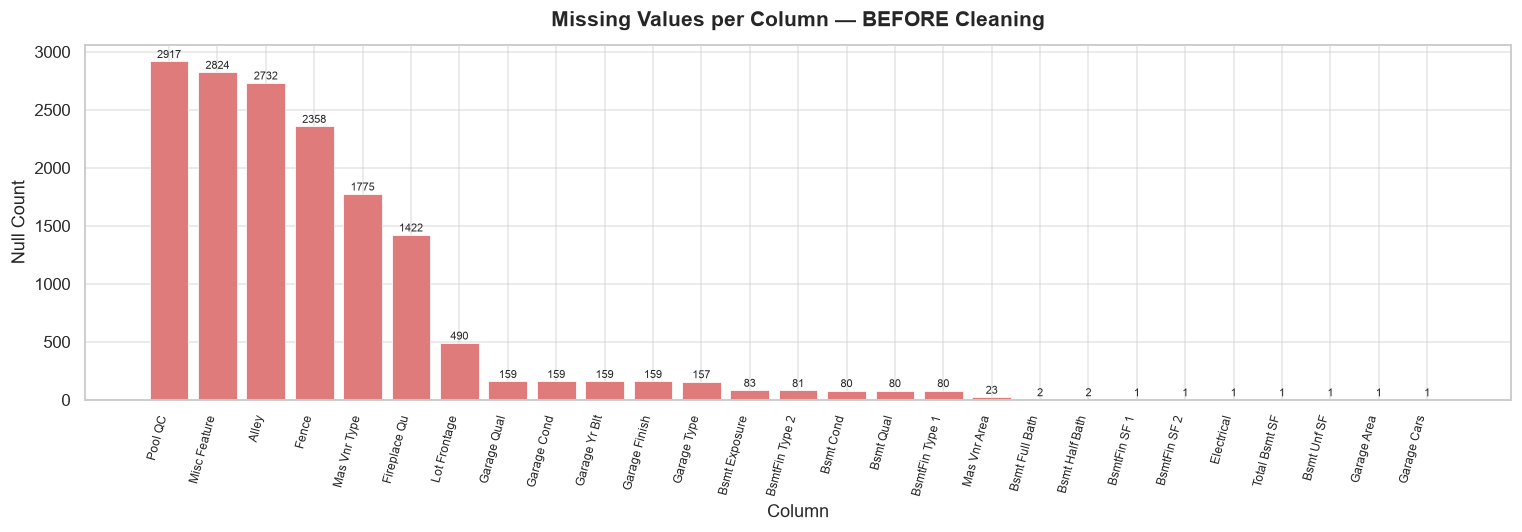

Total null cells: 15749


In [5]:
# Null heatmap — BEFORE
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(null_counts.index, null_counts.values, color='#E07B7B', edgecolor='white', linewidth=0.5)
ax.set_title('Missing Values per Column — BEFORE Cleaning', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Column')
ax.set_ylabel('Null Count')
ax.set_xticklabels(null_counts.index, rotation=75, ha='right', fontsize=8)
for bar, val in zip(bars, null_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('before_nulls.png', bbox_inches='tight')
plt.show()
print(f"Total null cells: {df.isnull().sum().sum()}")


## 3. Null Value Handling

**Strategy:**
- Columns where `NaN` means *feature absent* → fill with `'None'` (categorical) or `0` (numerical)
- `Lot Frontage` (490 nulls) → fill with **median grouped by Neighborhood** (more accurate than global median)
- Remaining small-null numerical cols → fill with column median
- Single-null categorical → fill with mode


In [7]:
# --- Columns where NaN = feature doesn't exist ---
none_str_cols = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1',
    'BsmtFin Type 2', 'Mas Vnr Type'
]
none_num_cols = [
    'Garage Yr Blt', 'Garage Cars', 'Garage Area',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
    'Bsmt Full Bath', 'Bsmt Half Bath', 'Mas Vnr Area'
]

for col in none_str_cols:
    df[col] = df[col].fillna('None')

for col in none_num_cols:
    df[col] = df[col].fillna(0)

df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median())
)
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())


df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print("Nulls remaining after handling:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all nulls resolved ✓")
print(f"\nTotal null cells: {df.isnull().sum().sum()}")


Nulls remaining after handling:
None — all nulls resolved ✓

Total null cells: 0


C:\Users\Bilal Aamir\AppData\Local\Temp\ipykernel_23260\1527631529.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(null_before.index, rotation=80, ha='right', fontsize=7)
C:\Users\Bilal Aamir\AppData\Local\Temp\ipykernel_23260\1527631529.py:24: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Bilal Aamir\AppData\Local\Temp\ipykernel_23260\1527631529.py:25: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('compare_nulls.png', bbox_inches='tight')
C:\Users\Bilal Aamir\PycharmProjects\Internship Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


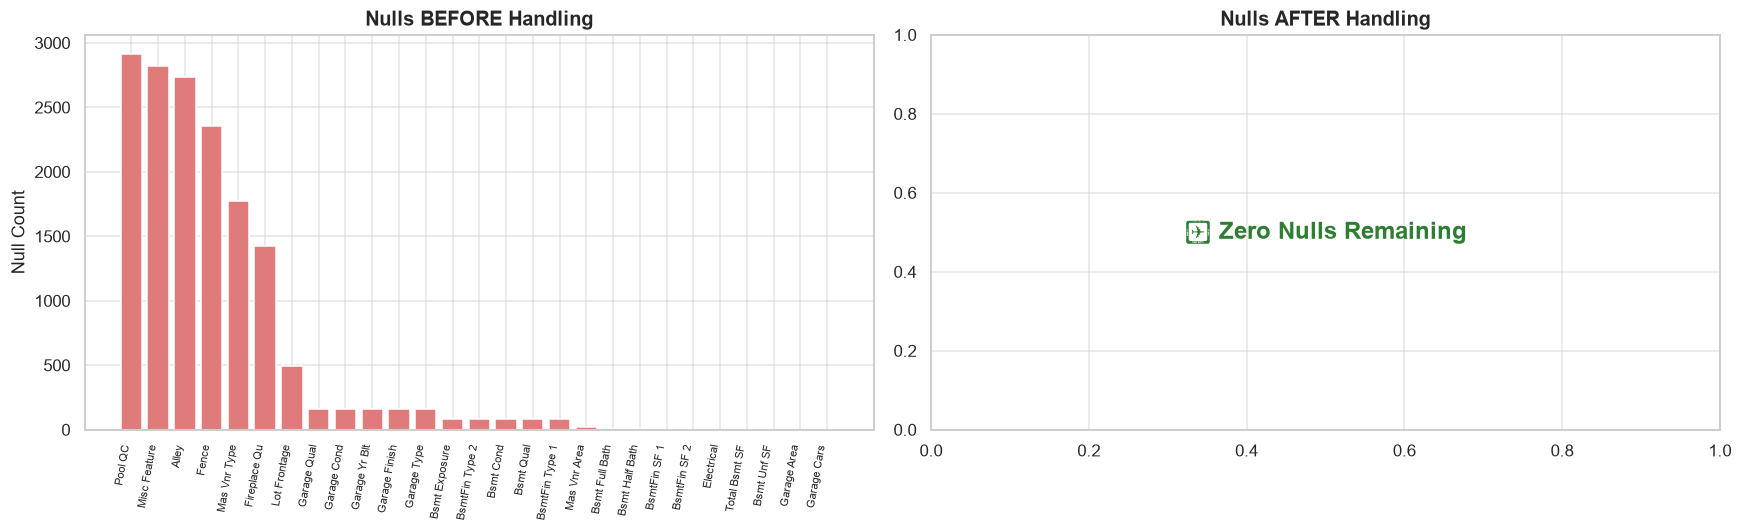

In [8]:
# Null heatmap — AFTER
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before
null_before = df_raw.isnull().sum()
null_before = null_before[null_before > 0].sort_values(ascending=False)
axes[0].bar(null_before.index, null_before.values, color='#E07B7B', edgecolor='white')
axes[0].set_title('Nulls BEFORE Handling', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(null_before.index, rotation=80, ha='right', fontsize=7)
axes[0].set_ylabel('Null Count')

# After
null_after = df.isnull().sum()
null_after_nonzero = null_after[null_after > 0]
if len(null_after_nonzero) > 0:
    axes[1].bar(null_after_nonzero.index, null_after_nonzero.values, color='#7BB87E', edgecolor='white')
else:
    axes[1].text(0.5, 0.5, '✓ Zero Nulls Remaining', ha='center', va='center',
                 fontsize=16, color='#2E7D32', transform=axes[1].transAxes,
                 fontweight='bold')
    axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].set_title('Nulls AFTER Handling', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('compare_nulls.png', bbox_inches='tight')
plt.show()


## 4. Drop Low-Value Columns

In [9]:
# Order and PID are identifiers — no predictive value
df.drop(columns=['Order', 'PID'], inplace=True)

# Utilities has near-zero variance (almost all rows = 'AllPub')
print("Utilities value counts:")
print(df['Utilities'].value_counts())
df.drop(columns=['Utilities'], inplace=True)

print(f"\nShape after dropping identifier/low-variance cols: {df.shape}")


Utilities value counts:
Utilities
AllPub    2927
NoSewr       2
NoSeWa       1
Name: count, dtype: int64

Shape after dropping identifier/low-variance cols: (2930, 79)


## 5. Outlier Removal

Two well-known outliers in Ames Housing:
- `Gr Liv Area` > 4000 sqft with unusually low sale price (partial sales)
- `SalePrice` extreme high-end via IQR rule


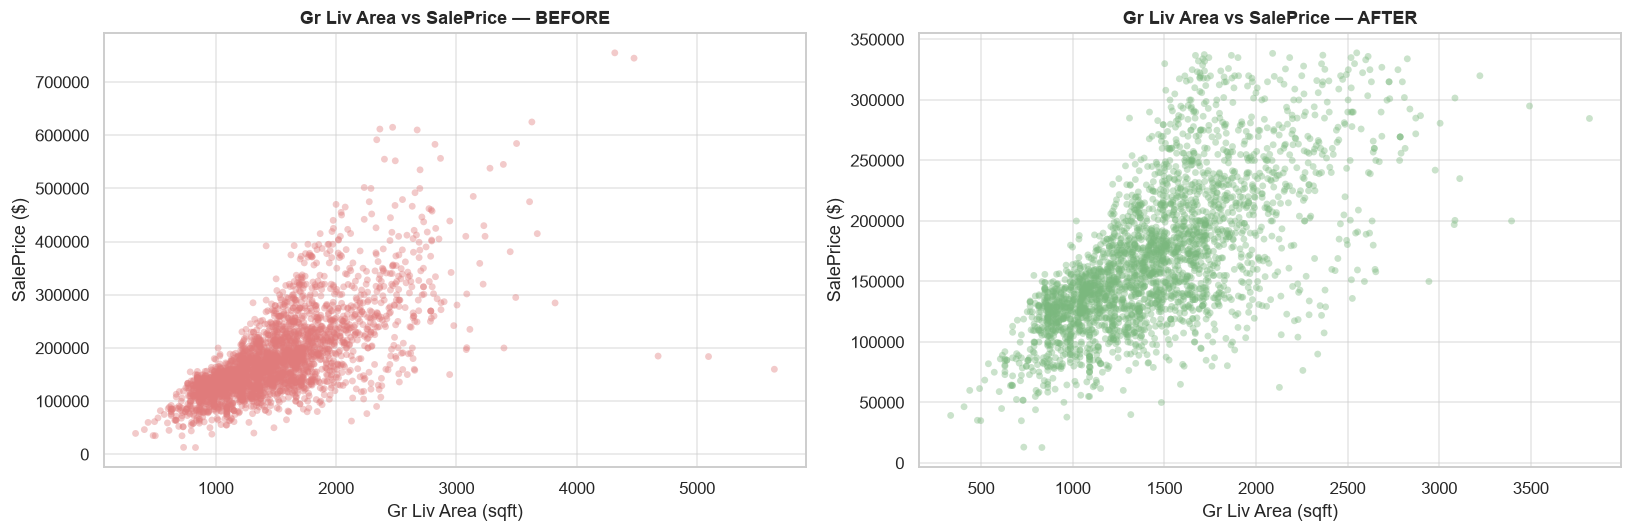

Rows before: 2930
Rows after:  2790
Removed:     140 outlier rows


In [10]:
# --- Before: scatter plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(df['Gr Liv Area'], df['SalePrice'],
                alpha=0.4, color='#E07B7B', edgecolors='none', s=20)
axes[0].set_title('Gr Liv Area vs SalePrice — BEFORE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gr Liv Area (sqft)'); axes[0].set_ylabel('SalePrice ($)')

rows_before = df.shape[0]

# --- Remove known partial-sale outliers (Gr Liv Area > 4000 & low price) ---
df = df[~((df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000))]

# --- IQR filter on SalePrice ---
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['SalePrice'] >= lower) & (df['SalePrice'] <= upper)]

rows_after = df.shape[0]

axes[1].scatter(df['Gr Liv Area'], df['SalePrice'],
                alpha=0.4, color='#7BB87E', edgecolors='none', s=20)
axes[1].set_title('Gr Liv Area vs SalePrice — AFTER', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gr Liv Area (sqft)'); axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.savefig('compare_outliers.png', bbox_inches='tight')
plt.show()

print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Removed:     {rows_before - rows_after} outlier rows")


## 6. Ordinal Encoding

Quality/condition columns follow a natural order (`Ex > Gd > TA > Fa > Po > None`).  
Map them to integers so the model understands the ordering.


In [11]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
bsmtfin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
functional_map = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,
                  'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}
slope_map = {'Gtl': 1, 'Mod': 2, 'Sev': 3}
paved_map = {'N': 0, 'P': 1, 'Y': 2}

ordinal_mappings = {
    'Exter Qual': qual_map, 'Exter Cond': qual_map,
    'Bsmt Qual': qual_map,  'Bsmt Cond': qual_map,
    'Heating QC': qual_map, 'Kitchen Qual': qual_map,
    'Fireplace Qu': qual_map, 'Garage Qual': qual_map,
    'Garage Cond': qual_map, 'Pool QC': qual_map,
    'Garage Finish': finish_map,
    'Bsmt Exposure': exposure_map,
    'BsmtFin Type 1': bsmtfin_map, 'BsmtFin Type 2': bsmtfin_map,
    'Functional': functional_map,
    'Land Slope': slope_map,
    'Paved Drive': paved_map,
}

print("Sample BEFORE encoding:")
print(df[['Exter Qual', 'Kitchen Qual', 'Bsmt Qual']].head(5))

for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)

print("\nSample AFTER encoding:")
print(df[['Exter Qual', 'Kitchen Qual', 'Bsmt Qual']].head(5))


Sample BEFORE encoding:
  Exter Qual Kitchen Qual Bsmt Qual
0         TA           TA        TA
1         TA           TA        TA
2         TA           Gd        TA
3         Gd           Ex        TA
4         TA           TA        Gd

Sample AFTER encoding:
   Exter Qual  Kitchen Qual  Bsmt Qual
0           3             3          3
1           3             3          3
2           3             4          3
3           4             5          3
4           3             3          4


## 7. One-Hot Encoding (Nominal Columns)

Remaining string columns have no natural order → one-hot encode them.


In [13]:
nominal_cols = df.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

print(f"Nominal columns to one-hot encode ({len(nominal_cols)}):")
print(nominal_cols)

cols_before = df.shape[1]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
cols_after = df.shape[1]

print(f"\nColumns before OHE: {cols_before}")
print(f"Columns after OHE:  {cols_after}")
print(f"Shape: {df.shape}")

Nominal columns to one-hot encode (0):
[]

Columns before OHE: 215
Columns after OHE:  215
Shape: (2790, 215)


## 8. Feature Engineering

Creating meaningful features from existing columns:

| Feature | Formula | Rationale |
|---|---|---|
| `HouseAge` | `Yr Sold - Year Built` | Older houses typically sell for less |
| `TotalSF` | `Total Bsmt SF + 1st Flr SF + 2nd Flr SF` | Total livable area is a strong price predictor |
| `TotalBath` | `Full Bath + 0.5×Half Bath + Bsmt Full Bath + 0.5×Bsmt Half Bath` | Weighted bathroom count |
| `IsRemod` | `1 if Year Remod/Add ≠ Year Built else 0` | Binary remodel flag |
| `OverallScore` | `Overall Qual × Overall Cond` | Interaction: quality × condition |
| `PorchSF` | Sum of all porch areas | Consolidated outdoor space metric |


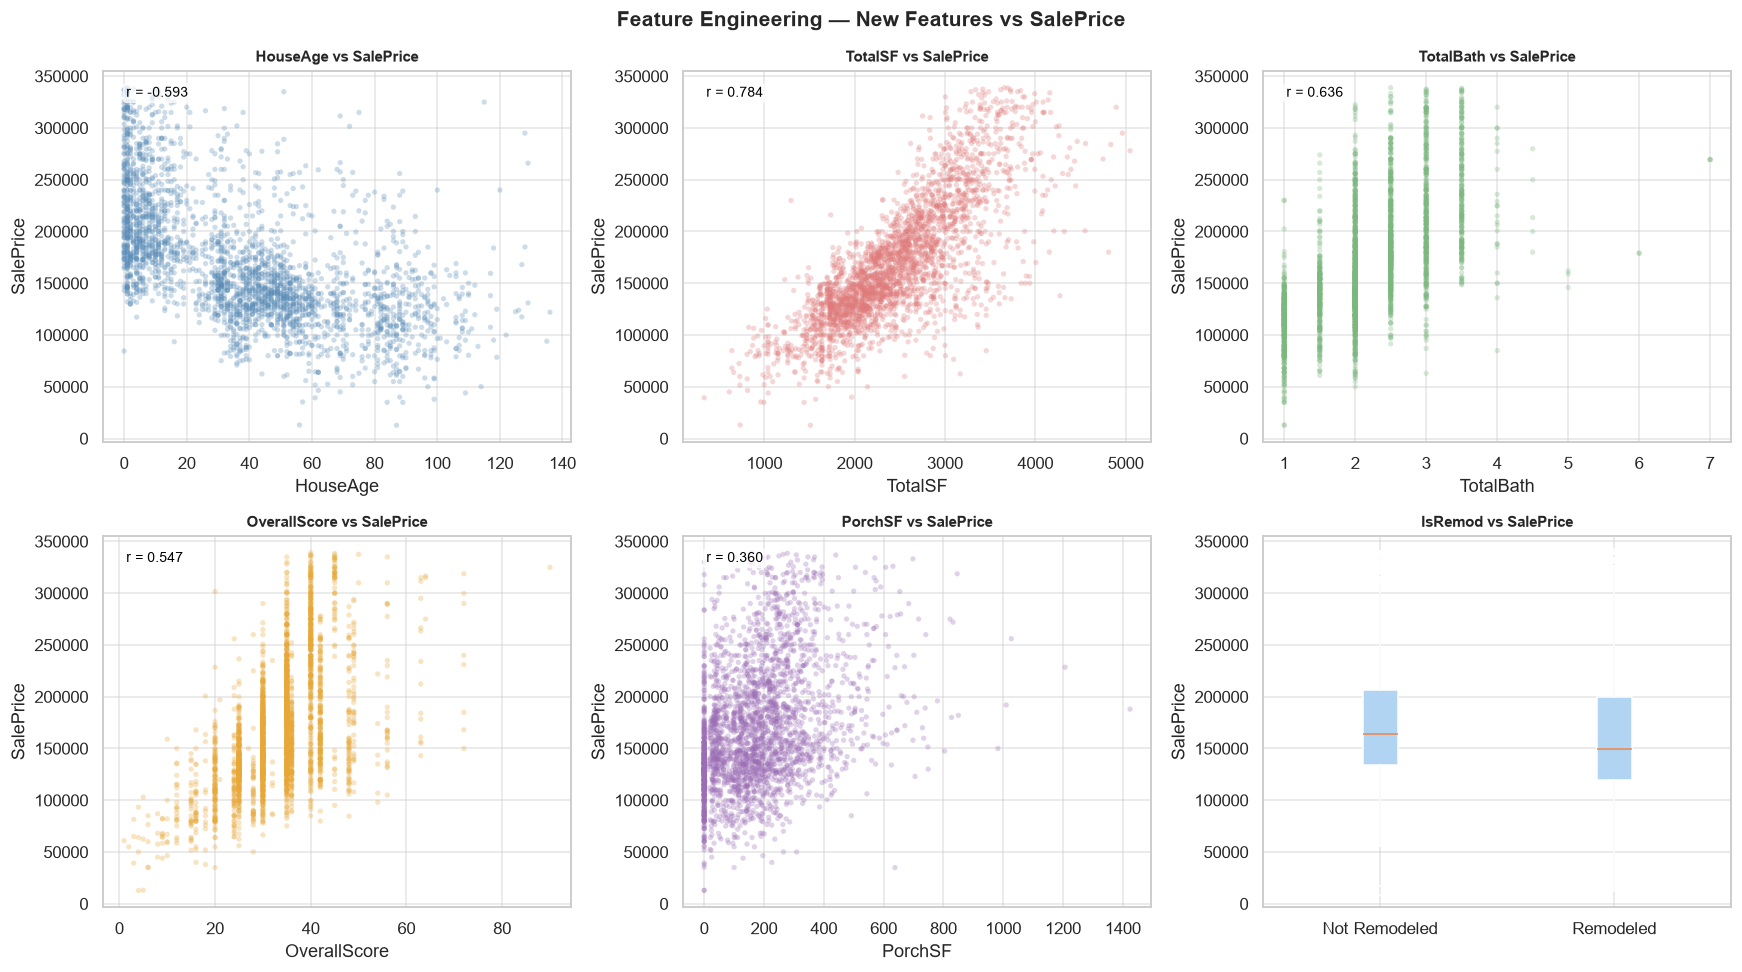

Engineered features added:
       HouseAge  TotalSF  TotalBath  IsRemod  OverallScore  PorchSF
count   2790.00  2790.00    2790.00  2790.00       2790.00  2790.00
mean      37.94  2455.76       2.16     0.46         33.20   175.46
std       30.08   670.41       0.78     0.50          8.94   154.88
min        0.00   334.00       1.00     0.00          1.00     0.00
25%        9.00  1976.00       1.50     0.00         30.00    44.00
50%       36.00  2400.00       2.00     0.00         35.00   160.00
75%       56.00  2888.75       2.50     1.00         40.00   256.00
max      136.00  5048.00       7.00     1.00         90.00  1424.00


In [15]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Engineering — New Features vs SalePrice', fontsize=14, fontweight='bold')


df['HouseAge']     = df['Yr Sold'] - df['Year Built']
df['TotalSF']      = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
df['TotalBath']    = (df['Full Bath'] + 0.5 * df['Half Bath'] +
                      df['Bsmt Full Bath'] + 0.5 * df['Bsmt Half Bath'])
df['IsRemod']      = (df['Year Remod/Add'] != df['Year Built']).astype(int)
df['OverallScore'] = df['Overall Qual'] * df['Overall Cond']
df['PorchSF']      = (df['Wood Deck SF'] + df['Open Porch SF'] +
                      df['Enclosed Porch'] + df['3Ssn Porch'] + df['Screen Porch'])

new_features = ['HouseAge', 'TotalSF', 'TotalBath', 'OverallScore', 'PorchSF']
colors = ['#5B8DB8', '#E07B7B', '#7BB87E', '#E8A838', '#9B6DB5']

for ax, feat, color in zip(axes.flatten()[:5], new_features, colors):
    ax.scatter(df[feat], df['SalePrice'], alpha=0.3, s=12, color=color, edgecolors='none')
    ax.set_xlabel(feat); ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice', fontsize=10, fontweight='bold')
    corr = df[feat].corr(df['SalePrice'])
    ax.text(0.05, 0.93, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=9, color='black',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

axes[1][2].boxplot([df[df['IsRemod']==0]['SalePrice'],
                    df[df['IsRemod']==1]['SalePrice']],
                   tick_labels=['Not Remodeled', 'Remodeled'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#B0D4F1'))
axes[1][2].set_title('IsRemod vs SalePrice', fontsize=10, fontweight='bold')
axes[1][2].set_ylabel('SalePrice')

plt.tight_layout()
plt.savefig('feature_engineering.png', bbox_inches='tight')
plt.show()

print("Engineered features added:")
print(df[['HouseAge','TotalSF','TotalBath','IsRemod','OverallScore','PorchSF']].describe().round(2))

## 9. Feature Scaling (Min-Max Normalization)

Scale continuous numerical features to [0, 1] range.  
Boolean/flag columns and the target `SalePrice` are excluded.


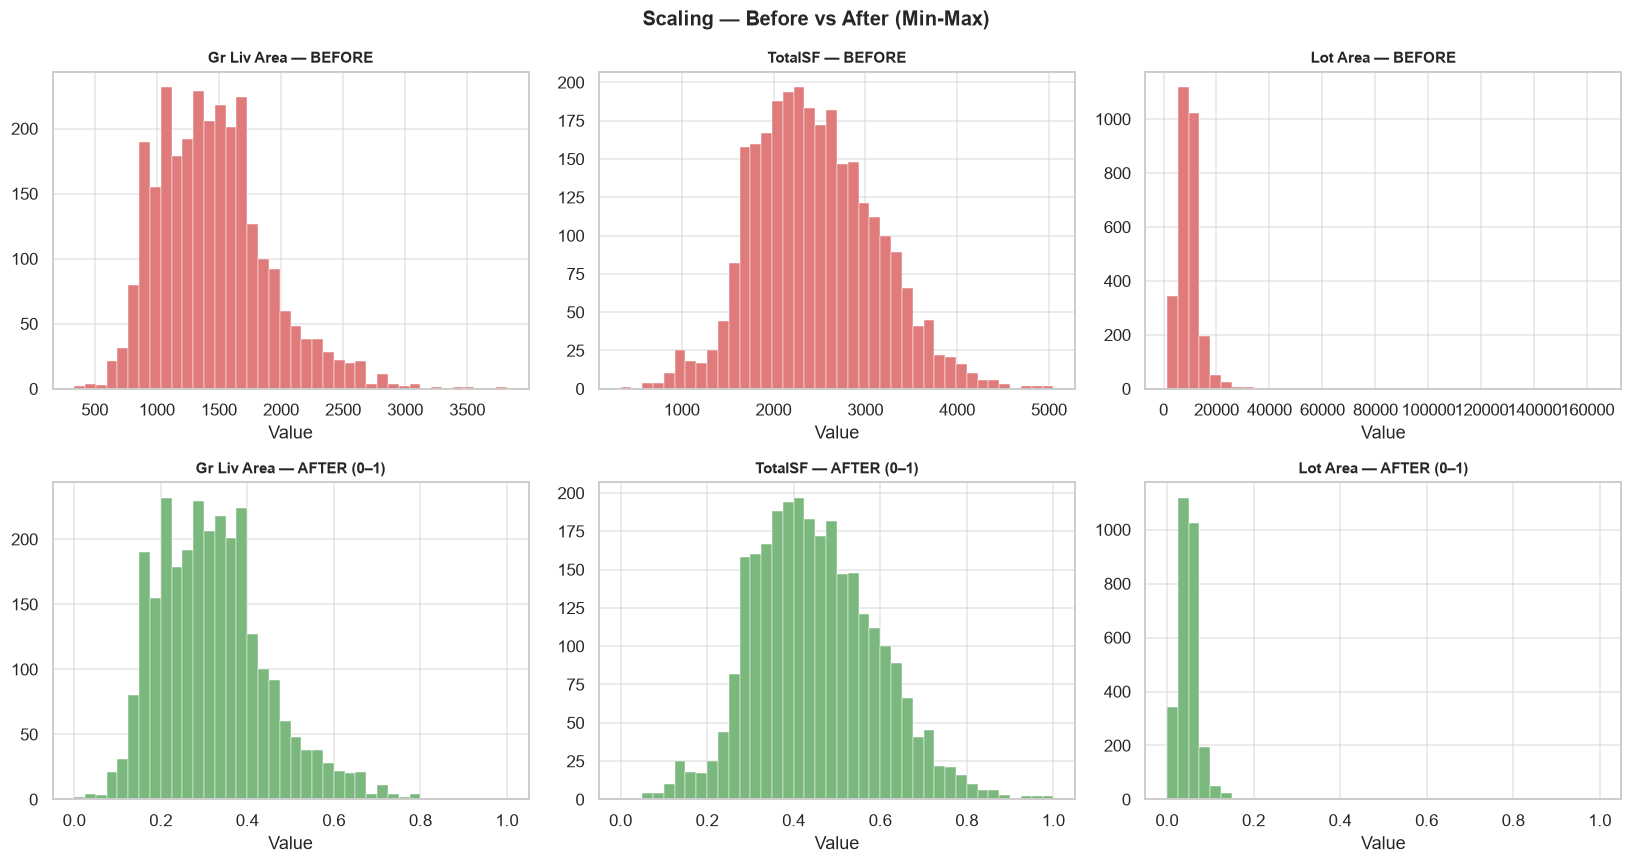

Scaled columns range check (should be 0.0 – 1.0):
     Gr Liv Area  TotalSF  Lot Area
min          0.0      0.0       0.0
max          1.0      1.0       1.0


In [16]:
scale_cols = [
    'Lot Frontage', 'Lot Area', 'Mas Vnr Area',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
    '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
    'Garage Yr Blt', 'Garage Area',
    'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
    '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val',
    'HouseAge', 'TotalSF', 'TotalBath', 'OverallScore', 'PorchSF'
]

# Only scale columns that actually exist in df after OHE
scale_cols = [c for c in scale_cols if c in df.columns]

# Before/After comparison for 3 key columns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Scaling — Before vs After (Min-Max)', fontsize=13, fontweight='bold')

preview_cols = ['Gr Liv Area', 'TotalSF', 'Lot Area']
for i, col in enumerate(preview_cols):
    axes[0][i].hist(df[col], bins=40, color='#E07B7B', edgecolor='white', linewidth=0.3)
    axes[0][i].set_title(f'{col} — BEFORE', fontsize=10, fontweight='bold')
    axes[0][i].set_xlabel('Value')

scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

for i, col in enumerate(preview_cols):
    axes[1][i].hist(df[col], bins=40, color='#7BB87E', edgecolor='white', linewidth=0.3)
    axes[1][i].set_title(f'{col} — AFTER (0–1)', fontsize=10, fontweight='bold')
    axes[1][i].set_xlabel('Value')

plt.tight_layout()
plt.savefig('compare_scaling.png', bbox_inches='tight')
plt.show()

print("Scaled columns range check (should be 0.0 – 1.0):")
print(df[preview_cols].agg(['min','max']).round(4))


## 10. Before vs After Summary

        BEFORE vs AFTER SUMMARY
  Rows        :   2930  →    2790
  Columns     :     82  →     221
  Null cells  :  15749  →       0
  String cols :     43  →       0
  New features:         +6 engineered


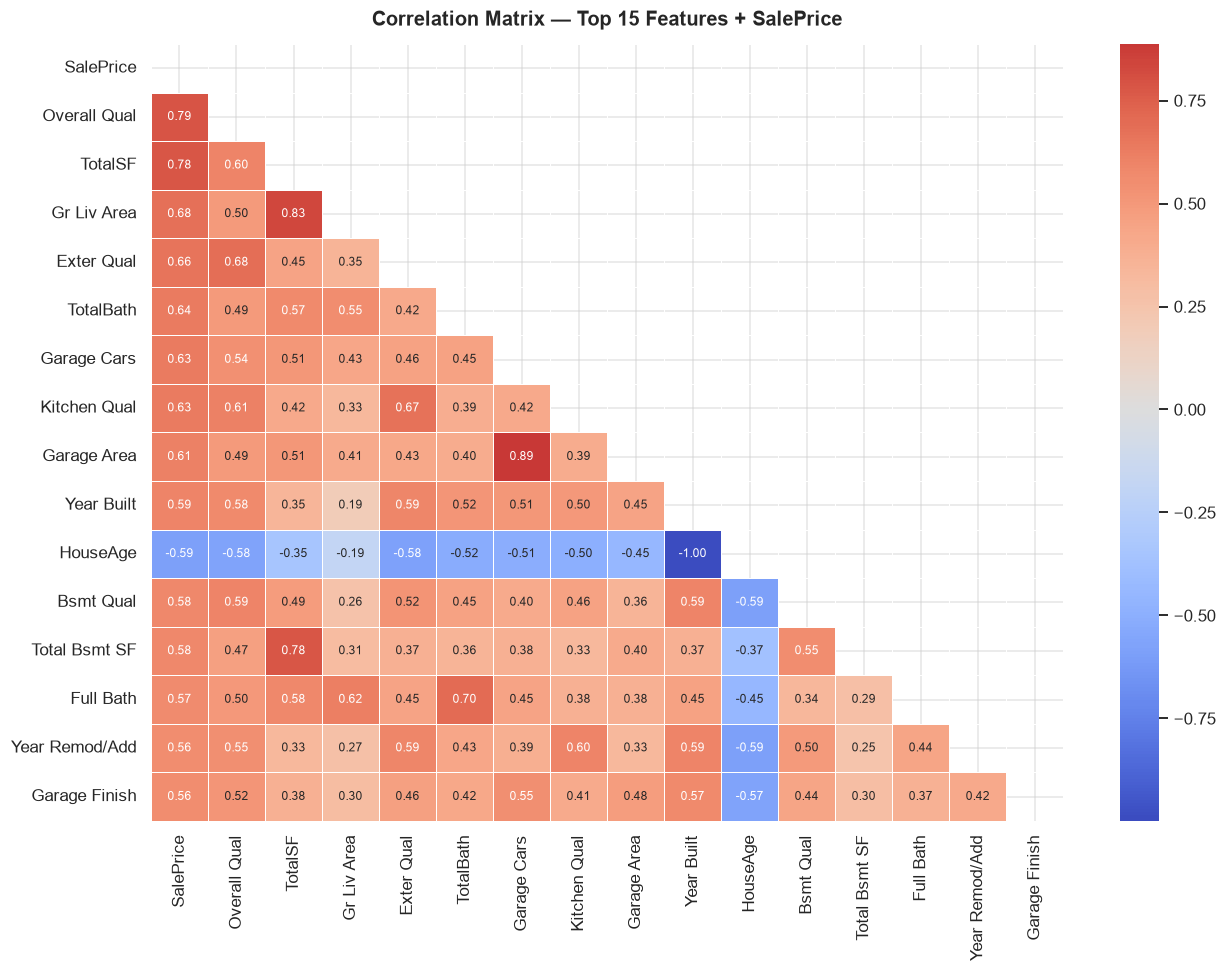

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("        BEFORE vs AFTER SUMMARY")

print(f"  Rows        : {df_raw.shape[0]:>6}  →  {df.shape[0]:>6}")
print(f"  Columns     : {df_raw.shape[1]:>6}  →  {df.shape[1]:>6}")
print(f"  Null cells  : {df_raw.isnull().sum().sum():>6}  →  {df.isnull().sum().sum():>6}")

# Updated line: Explicitly including 'object', 'str', and 'category' for both dataframes
print(f"  String cols : {df_raw.select_dtypes(include=['object', 'str', 'category']).shape[1]:>6}  →  {df.select_dtypes(include=['object', 'str', 'category']).shape[1]:>6}")

print(f"  New features:         +6 engineered")


# Correlation heatmap — top features vs SalePrice
top_corr = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(16)
top_cols = top_corr.index.tolist()
corr_matrix = df[top_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Top 15 Features + SalePrice', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 11. Export Cleaned Dataset

In [21]:
df.to_csv('ames_cleaned.csv', index=False)
print(f"Saved: Ames Cleaned.csv")
print(f"Final shape: {df.shape}")
print(f"Columns preview: {list(df.columns[:10])} ...")


Saved: Ames Cleaned.csv
Final shape: (2790, 221)
Columns preview: ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Land Slope', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'Exter Qual'] ...
